In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
human_scores = pd.read_csv("annotated_confidence_data.csv")
api_scores = pd.read_csv("api_eval_results.csv")
local_scores = pd.read_csv("local_eval_results.csv")

In [3]:
def remove_outliers(values):
    arr = np.asarray(values, dtype=float)
    if len(arr) == 0:
        return np.array([np.nan])
    q1, q3 = np.percentile(arr, [25, 75])
    iqr = q3 - q1
    if iqr == 0:
        return arr
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    return arr[(arr >= lower) & (arr <= upper)]

In [4]:
human_scores["annotated_scores"] = human_scores["annotated_scores"].apply(lambda x: eval(x))
human_scores["annotated_scores"] = human_scores["annotated_scores"].apply(remove_outliers)
human_scores["annotated_scores"] = human_scores["annotated_scores"].apply(lambda x: np.mean(x))
api_scores["scores"] = api_scores["scores"].apply(lambda x: eval(x))
local_scores["scores"] = local_scores["scores"].apply(lambda x: eval(x))

In [5]:
human_scores["llm_scores"] = (api_scores["scores"] + local_scores["scores"])
human_scores["llm_scores"] = human_scores["llm_scores"].apply(remove_outliers)
human_scores.dropna(inplace=True)
human_scores

,Unnamed: 0,uncertainty_expression,llm_confidence_level,annotated_scores,llm_scores
0,1,All signs point to Linus Pauling.,moderate,0.6080,"[0.8, 0.8, 0.8, 0.95, 0.9, 0.9]"
1,14,I believe Airrack hosted the 12th Streamy Awards.,moderate,0.6220,"[0.7, 0.7, 0.7, 0.6, 0.5, 0.45]"
2,35,The municipality seems to have been establishe...,moderate,0.6360,"[0.4, 0.4, 0.4, 0.3, 0.25]"
3,46,It seems to me that Fatima Sydow was 50 years ...,moderate,0.6140,"[0.4, 0.4, 0.4, 0.5, 0.5]"
4,54,The answer seems to be Pople.,moderate,0.6375,"[0.7, 0.6, 0.7, 0.6, 0.6, 0.6]"
...,...,...,...,...,...
1617,9980,"As far as I know, the DOI is 10.1515/thli.2008...",moderate,0.6680,"[0.7, 0.7, 0.7, 0.1, 0.65, 0.1]"
1618,9981,I’m fairly sure it happened in February 2008.,moderate,0.6680,"[0.7, 0.7, 0.7, 0.7, 0.65, 0.7]"
1619,9984,I’m inclined to think that Aston Villa ended t...,moderate,0.6860,"[0.4, 0.4, 0.4, 0.3, 0.5]"
1620,9992,The engineer was probably British.,moderate,0.6700,"[0.4, 0.4, 0.4, 0.4, 0.3]"


In [6]:
human_scores["llm_scores"] = human_scores["llm_scores"].apply(np.mean)

In [7]:
human_scores[["annotated_scores", "llm_scores", "llm_confidence_level"]]

,annotated_scores,llm_scores,llm_confidence_level
0,0.6080,0.858333,moderate
1,0.6220,0.608333,moderate
2,0.6360,0.350000,moderate
3,0.6140,0.440000,moderate
4,0.6375,0.633333,moderate
...,...,...,...
1617,0.6680,0.491667,moderate
1618,0.6680,0.691667,moderate
1619,0.6860,0.400000,moderate
1620,0.6700,0.380000,moderate


In [8]:
human_scores[["annotated_scores", "llm_scores"]].corr()

,annotated_scores,llm_scores
annotated_scores,1.000000,0.744166
llm_scores,0.744166,1.000000


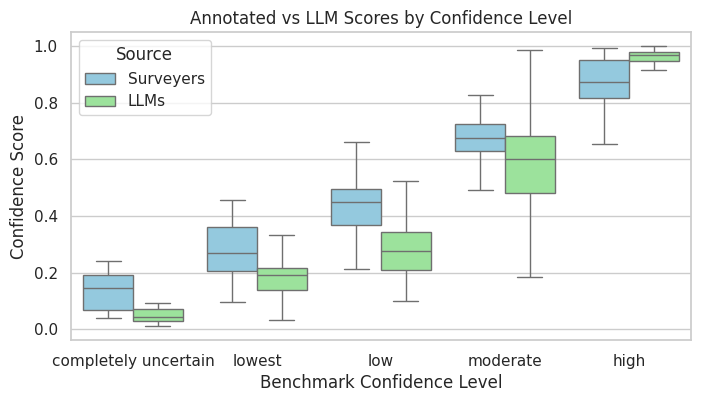

In [9]:
# Convert to long format for seaborn
df_long = human_scores.melt(
    id_vars=['llm_confidence_level'],
    value_vars=['annotated_scores', 'llm_scores'],
    var_name='source',
    value_name='score'
)
df_long['source'] = df_long['source'].map({
    'annotated_scores': 'Surveyers',
    'llm_scores': 'LLMs',
})

# Define the specific order for confidence levels
level_order = ['completely uncertain', 'lowest', 'low', 'moderate', 'high']

sns.set_theme(style="whitegrid")

plt.figure(figsize=(8,4))
sns.boxplot(
    x='llm_confidence_level',
    y='score',
    hue='source',
    data=df_long,
    showfliers=False,
    palette=['skyblue', 'lightgreen'],
    order=level_order
)

plt.title('Annotated vs LLM Scores by Confidence Level')
plt.xlabel('Benchmark Confidence Level')
plt.ylabel('Confidence Score')
plt.legend(title='Source')
plt.savefig('annotated_vs_llm_scores_boxplots.pdf', dpi=300, bbox_inches='tight')

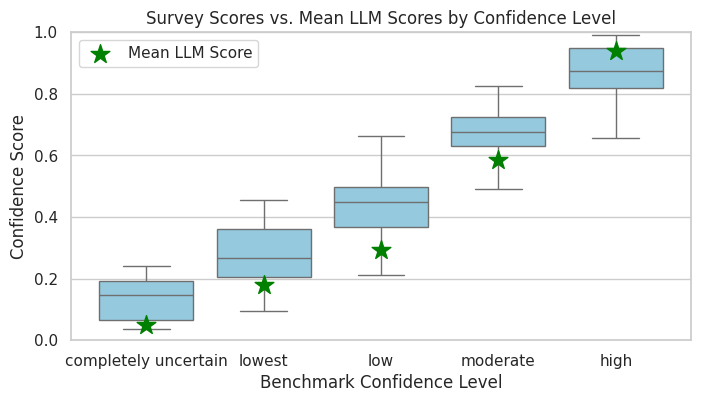

In [12]:
# Suppose human_scores already has columns: ['annotated_scores', 'llm_scores', 'llm_confidence_level']

# Define order of confidence levels
level_order = ['completely uncertain', 'lowest', 'low', 'moderate', 'high']

sns.set_theme(style="whitegrid")
plt.figure(figsize=(8, 4))

# Boxplot for human/annotated scores
sns.boxplot(
    x='llm_confidence_level',
    y='annotated_scores',
    data=human_scores,
    order=level_order,
    color='skyblue',
    showfliers=False
)

# Compute mean LLM score per confidence level
llm_means = human_scores.groupby('llm_confidence_level')['llm_scores'].mean().reindex(level_order)

# Overlay mean LLM scores as points
plt.scatter(
    x=range(len(llm_means)),  # positions corresponding to x-axis categories
    y=llm_means.values,
    color='green',
    s=200,
    zorder=10,
    label='Mean LLM Score',
    marker='*',
)

plt.title('Survey Scores vs. Mean LLM Scores by Confidence Level')
plt.xlabel('Benchmark Confidence Level')
plt.ylabel('Confidence Score')
plt.ylim(0, 1)
plt.legend()
plt.savefig('annotated_vs_llm_scores_boxplots_1.pdf', dpi=300, bbox_inches='tight')